# Libraries

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# EDA

In [122]:
df = pd.read_csv("../data/pjm_noaa_merged.csv")

# Ensure DATE is datetime
df['DATE'] = pd.to_datetime(df['DATE'])

In [123]:
print(df.describe())

# Check missing values
print(df.isna().sum())

print(df.columns)

              demand                        DATE         AWND         PRCP  \
count    5000.000000                        5000  5000.000000  5000.000000   
mean   116538.785800  2023-08-15 08:40:24.960000     9.065200     0.147282   
min      3748.000000         2022-04-01 00:00:00     1.790000     0.000000   
25%    101908.000000         2022-12-07 18:00:00     6.490000     0.000000   
50%    110951.500000         2023-08-15 00:00:00     8.500000     0.000000   
75%    125399.000000         2024-04-23 00:00:00    11.180000     0.070000   
max    203751.000000         2024-12-31 00:00:00    22.590000     5.590000   
std     22319.782566                         NaN     3.472964     0.426424   

              TAVG         TMAX        TMIN  
count  5000.000000  5000.000000  5000.00000  
mean     60.088200    67.460200    47.52700  
min      11.000000    18.000000     5.00000  
25%      47.000000    54.000000    35.00000  
50%      61.000000    70.000000    47.00000  
75%      74.000000   

# Distributions

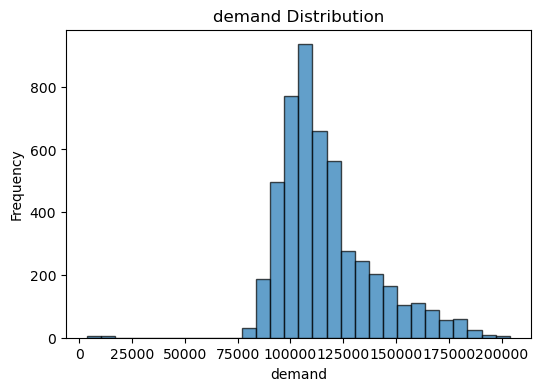

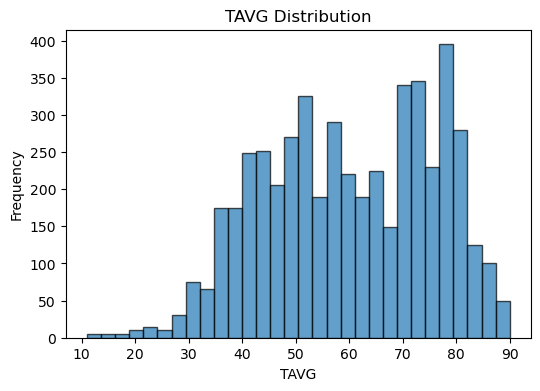

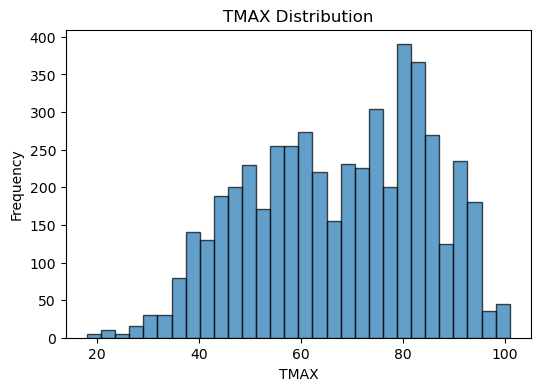

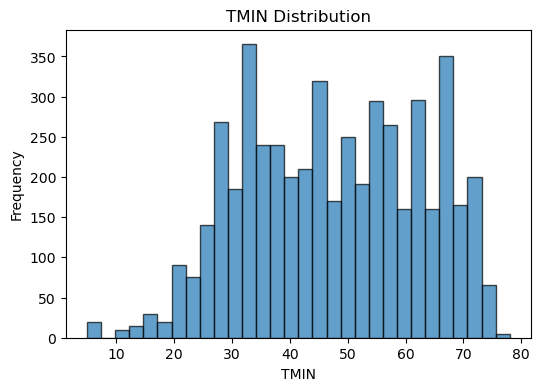

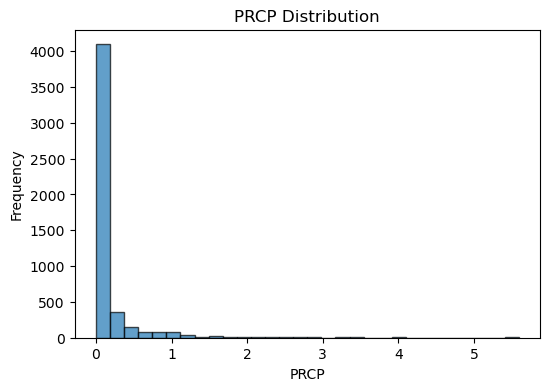

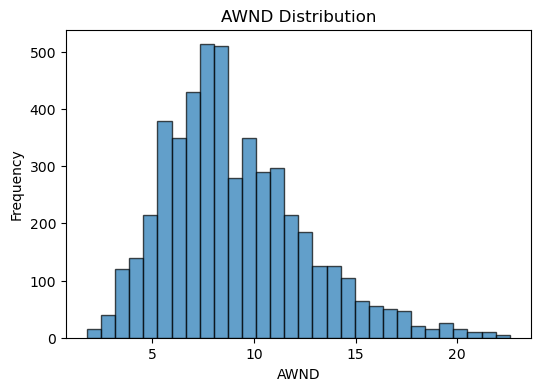

In [137]:
plot_cols = ["demand", "TAVG", "TMAX", "TMIN", "PRCP", "AWND"]

for col in plot_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30, edgecolor="k", alpha=0.7)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Relationships

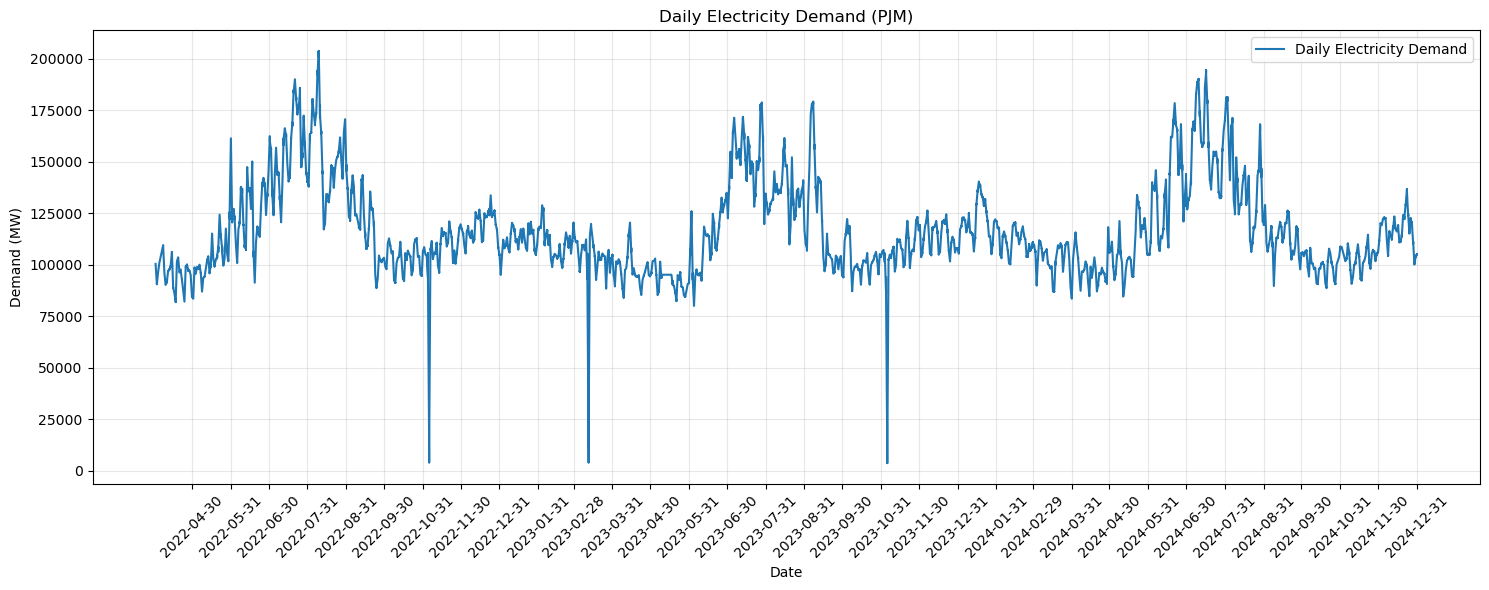

In [126]:
plt.figure(figsize=(15,6))
plt.plot(df['DATE'], df['demand'], label='Daily Electricity Demand')

# Use month-end ticks ('ME') to reduce clutter
plt.xticks(
    pd.date_range(start=df['DATE'].min(), end=df['DATE'].max(), freq='ME'),
    rotation=45
)

plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.title('Daily Electricity Demand (PJM)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

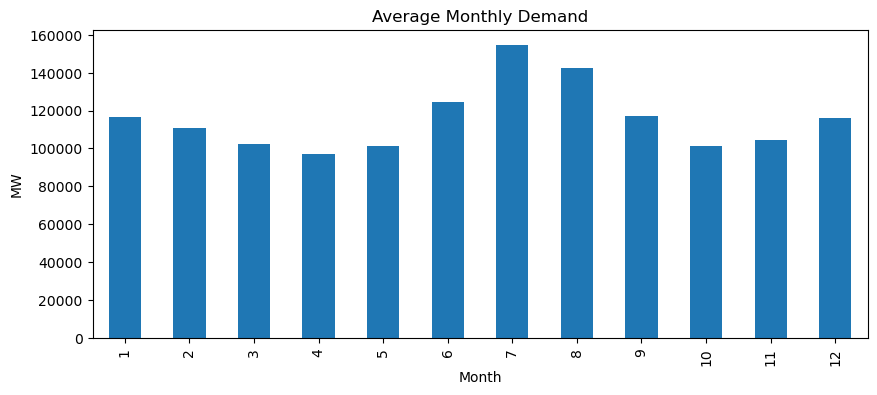

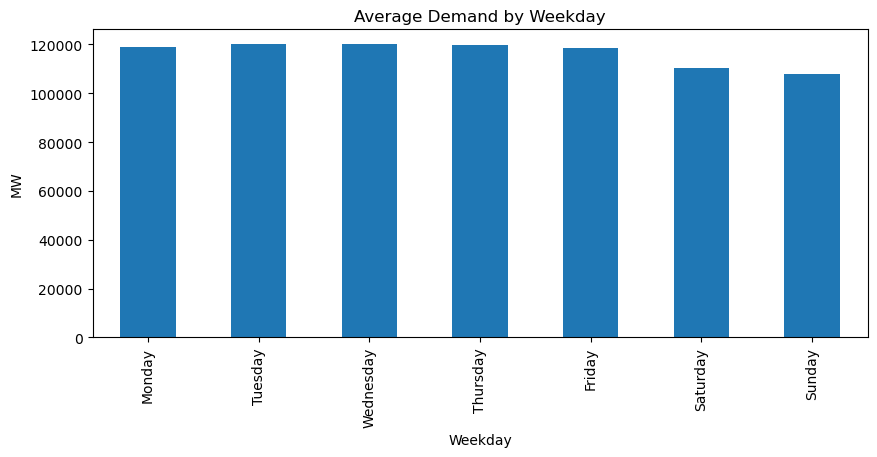

In [127]:
# Add Year, Month, Weekday columns
df['Year'] = df['DATE'].dt.year
df['Month'] = df['DATE'].dt.month
df['Weekday'] = df['DATE'].dt.day_name()

# Monthly 
monthly = df.groupby('Month')['demand'].mean()
monthly.plot(kind='bar', figsize=(10,4), title="Average Monthly Demand")
plt.ylabel("MW")
plt.show()

# Weekly 
weekday = df.groupby('Weekday')['demand'].mean()
weekday = weekday.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
weekday.plot(kind='bar', figsize=(10,4), title="Average Demand by Weekday")
plt.ylabel("MW")
plt.show()

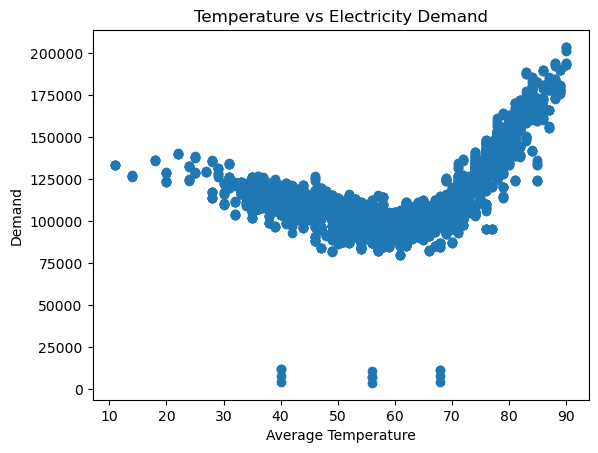

In [128]:
plt.scatter(df["TAVG"], df["demand"])
plt.xlabel("Average Temperature")
plt.ylabel("Demand")
plt.title("Temperature vs Electricity Demand")
plt.show()

## Correlations

In [129]:
df.columns

Index(['period', 'subba', 'subba-name', 'parent', 'parent-name', 'timezone',
       'demand', 'value-units', 'DATE', 'STATION', 'NAME', 'AWND', 'PRCP',
       'TAVG', 'TMAX', 'TMIN', 'Year', 'Month', 'Weekday'],
      dtype='object')

In [130]:
# Correlations with target after feature engineering 
corr = df.corr(numeric_only=True)["demand"].sort_values(ascending=False)
print(corr)

demand    1.000000
TMIN      0.544542
TAVG      0.510629
TMAX      0.466896
Month     0.085885
PRCP      0.044899
Year     -0.038768
AWND     -0.088010
Name: demand, dtype: float64


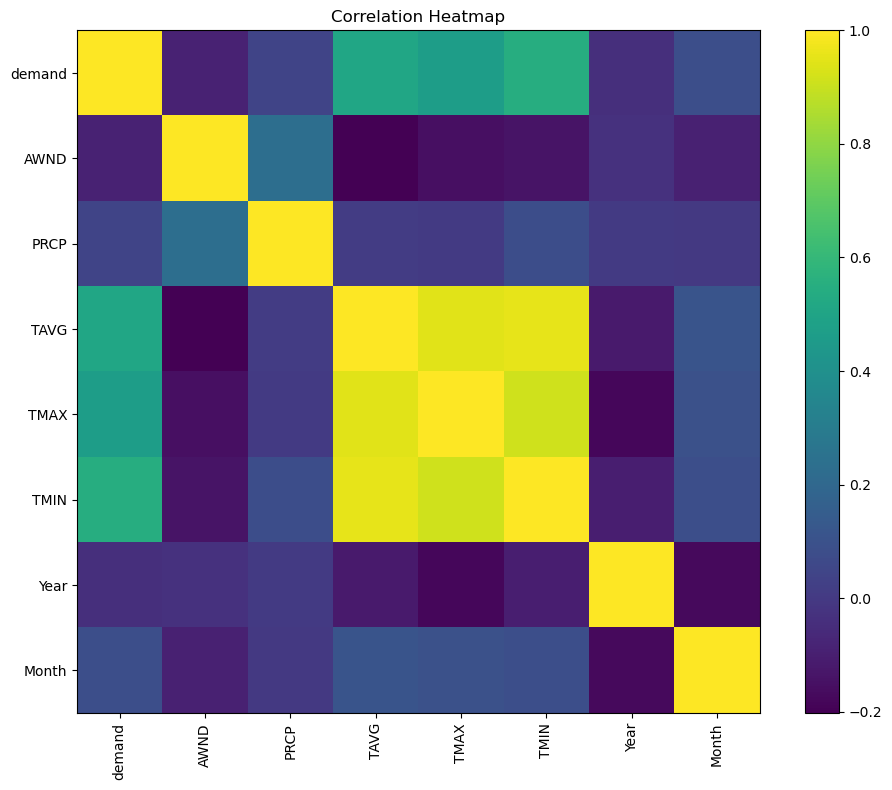

In [131]:
# select numeric columns
numeric_df = df.select_dtypes(include="number")

# correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)

plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

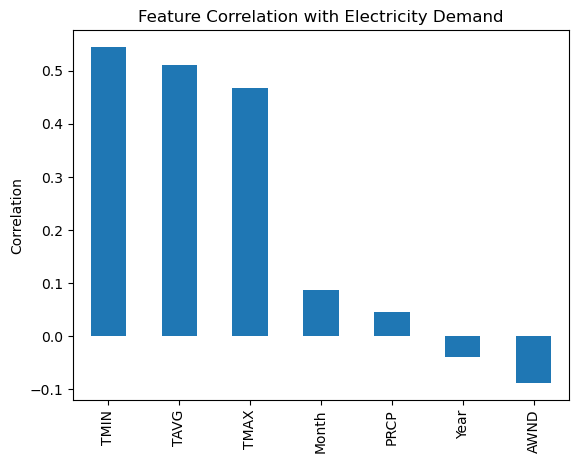

In [132]:
corr = df.corr(numeric_only=True)["demand"].sort_values(ascending=False)

# remove the target 
corr = corr.drop("demand")

corr.plot(kind="bar")

plt.title("Feature Correlation with Electricity Demand")
plt.ylabel("Correlation")
plt.show()